In [ ]:
import torch
import torch.nn as nn
import torch.multiprocessing as mp
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==================== Jupyter 多进程配置 ====================
# 启用 torch.multiprocessing 以支持多进程数据加载
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass  # 已经设置过启动方法

print("✓ Torch multiprocessing 已配置")


def detect_best_device():
    """自动选择最优设备并返回运行参数。"""
    if torch.cuda.is_available():
        return {
            'device': torch.device('cuda'),
            'backend': 'cuda',
            'pin_memory': True,
            'num_workers': min(8, max(2, (os.cpu_count() or 4) // 2)),
            'persistent_workers': True,
        }

    # Apple Silicon fallback (for cross-platform notebook portability)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return {
            'device': torch.device('mps'),
            'backend': 'mps',
            'pin_memory': True,
            'num_workers': 4,
            'persistent_workers': True,
        }

    # x86 CPU or other CPU-only environments
    return {
        'device': torch.device('cpu'),
        'backend': 'cpu',
        'pin_memory': False,
        'num_workers': 0,
        'persistent_workers': False,
    }


def resolve_project_sekai_dir():
    """从当前工作目录向上推导 ProjectSekai 项目根目录。"""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / 'Thelia' / 'ProjectSekai',
        cwd / 'ProjectSekai',
        cwd.parent / 'ProjectSekai',
        cwd.parent.parent / 'ProjectSekai',
        cwd,
    ]

    for candidate in candidates:
        if (candidate / 'TrainingData').exists() or (candidate / 'Codes').exists():
            return candidate

    raise FileNotFoundError(
        f'无法从当前工作目录 {cwd} 定位 ProjectSekai 目录，请确认 notebook 的启动位置。'
    )


runtime_cfg = detect_best_device()
device = runtime_cfg['device']
DATALOADER_NUM_WORKERS = runtime_cfg['num_workers']
DATALOADER_PIN_MEMORY = runtime_cfg['pin_memory']
DATALOADER_PERSISTENT_WORKERS = runtime_cfg['persistent_workers']

print(f"使用设备: {device}")
print(f"后端: {runtime_cfg['backend']}")
print(f"DataLoader workers: {DATALOADER_NUM_WORKERS}")
print(f"DataLoader pin_memory: {DATALOADER_PIN_MEMORY}")

# 基本配置
BASE_DIR = resolve_project_sekai_dir()
WORKSPACE_ROOT = BASE_DIR.parents[1]
TRAINING_DATA_DIR = BASE_DIR / 'TrainingData'
AUGMENTED_DATA_DIR = BASE_DIR / 'AugmentedTrainingData'
TRAIN_DATA_DIR = AUGMENTED_DATA_DIR / 'train'
TEST_DATA_DIR = AUGMENTED_DATA_DIR / 'test'
CODE_DIR = BASE_DIR / 'Codes'


def display_project_path(path):
    """将项目内路径显示为相对 workspace 的形式。"""
    try:
        return path.relative_to(WORKSPACE_ROOT)
    except ValueError:
        return path


# 超参数
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
RANDOM_SEED = 42
TEST_SPLIT_RATIO = 0.2

# 类别定义
CLASS_NAMES = ['Enanan', 'Kanade', 'Mafuyu', 'Mizuki']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print(f"配置信息:")
print(f"  原始训练数据目录: {display_project_path(TRAINING_DATA_DIR)}")
print(f"  增强后数据目录: {display_project_path(AUGMENTED_DATA_DIR)}")
print(f"  训练集目录: {display_project_path(TRAIN_DATA_DIR)}")
print(f"  测试集目录: {display_project_path(TEST_DATA_DIR)}")
print(f"  代码目录: {display_project_path(CODE_DIR)}")
print(f"  类别数: {NUM_CLASSES}")
print(f"  类别: {CLASS_NAMES}")
print(f"  批大小: {BATCH_SIZE}")
print(f"  学习率: {LEARNING_RATE}")
print(f"  最大epoch数: {NUM_EPOCHS}")
print(f"  测试集比例: {TEST_SPLIT_RATIO}")

✓ Torch multiprocessing 已配置
使用设备: mps
后端: mps
DataLoader workers: 8
DataLoader pin_memory: True
配置信息:
  原始训练数据目录: Thelia/ProjectSekai/TrainingData
  增强后数据目录: Thelia/ProjectSekai/AugmentedTrainingData
  训练集目录: Thelia/ProjectSekai/AugmentedTrainingData/train
  测试集目录: Thelia/ProjectSekai/AugmentedTrainingData/test
  代码目录: Thelia/ProjectSekai/Codes
  类别数: 4
  类别: ['Enanan', 'Kanade', 'Mafuyu', 'Mizuki']
  批大小: 128
  学习率: 0.001
  最大epoch数: 15
  测试集比例: 0.2


In [14]:
# ==================== Phase 0: 数据增强 + 原图级别随机切分 ====================
# 规则：先按原始图片分 train/test，再对每张原图生成 10 个变体
# 同一原图的所有增强样本会固定进入同一个集合；train/test 的变体都会加入轻微模糊与噪点

import random
import shutil
from PIL import ImageFilter

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def make_ten_variants(img):
    """对一张图片生成 10 个变体。"""
    return [
        ("original", img),
        ("h_flip", img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("v_flip", img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("hv_flip", img.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM)),
        ("rot90", img.rotate(90, expand=True)),
        ("rot180", img.rotate(180, expand=True)),
        ("rot270", img.rotate(270, expand=True)),
        ("rot45", img.rotate(45, expand=True)),
        ("rot135", img.rotate(135, expand=True)),
        ("rot315", img.rotate(315, expand=True)),
    ]


def prepare_output_dirs(base_dir, class_names):
    """创建 train/test 输出目录。"""
    if base_dir.exists():
        shutil.rmtree(base_dir)
    for split_name in ['train', 'test']:
        for class_name in class_names:
            (base_dir / split_name / class_name).mkdir(parents=True, exist_ok=True)


def get_source_files(class_source_dir):
    """获取原始 JPEG 文件，兼容 .jpg 和 .jpeg。"""
    jpg_files = sorted(class_source_dir.glob('*.jpg'))
    jpeg_files = sorted(class_source_dir.glob('*.jpeg'))
    return sorted(jpg_files + jpeg_files)


def split_files(file_list, test_ratio=0.2, seed=42):
    """按原图级别切分 train/test，返回 (train_files, test_files)。"""
    file_list = list(file_list)
    rng = random.Random(seed)
    rng.shuffle(file_list)
    test_size = max(1, int(round(len(file_list) * test_ratio))) if len(file_list) > 1 else len(file_list)
    test_files = file_list[:test_size]
    train_files = file_list[test_size:]
    return train_files, test_files


def save_variant_to_split(variant_img, output_dir, class_name, split_name, base_name, variant_name):
    """把单个变体保存到指定 split。"""
    target_dir = output_dir / split_name / class_name
    target_dir.mkdir(parents=True, exist_ok=True)
    variant_img.save(
        target_dir / f'{base_name}_{variant_name}.jpg',
        'JPEG',
        quality=95,
        optimize=True,
    )


def add_light_blur_and_noise(img, rng):
    """给图像添加轻微模糊与噪点。"""
    blurred = img.filter(ImageFilter.GaussianBlur(radius=0.6))
    arr = np.asarray(blurred).astype(np.float32)
    noise = rng.normal(loc=0.0, scale=4.0, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def augment_and_save_split(source_files, output_dir, class_name, split_name, seed=42):
    """对给定 split 的原图生成 10 个 JPEG 变体。"""
    rng = np.random.default_rng(seed)
    generated = 0
    for source_file in tqdm(source_files, desc=f"{class_name}-{split_name}"):
        try:
            img = Image.open(source_file).convert('RGB')
            base_name = source_file.stem
            for variant_name, variant_img in make_ten_variants(img):
                variant_img = add_light_blur_and_noise(variant_img, rng)
                save_variant_to_split(
                    variant_img,
                    output_dir,
                    class_name,
                    split_name,
                    base_name,
                    variant_name,
                )
                generated += 1
        except Exception as exc:
            print(f"  错误处理 {source_file.name}: {exc}")

    return generated


print("=" * 60)
print("开始数据增强：原图级别随机切分，同组样本保持在同一集合")
print("每张原图生成 10 个变体，train/test 都加入轻微模糊与噪点")
print("=" * 60)

prepare_output_dirs(AUGMENTED_DATA_DIR, CLASS_NAMES)

total_train_generated = 0
total_test_generated = 0
source_summary = {}

for class_name in CLASS_NAMES:
    class_source_dir = TRAINING_DATA_DIR / class_name
    source_files = get_source_files(class_source_dir)
    source_summary[class_name] = len(source_files)

    if not source_files:
        print(f"⚠ {class_name} 目录中没有找到 .jpg 或 .jpeg 文件: {class_source_dir}")
        continue

    train_files, test_files = split_files(source_files, test_ratio=TEST_SPLIT_RATIO, seed=RANDOM_SEED)
    print(f"\n{class_name}: 原始图片 {len(source_files)} 张, train {len(train_files)} 张, test {len(test_files)} 张")

    train_count = augment_and_save_split(
        train_files,
        AUGMENTED_DATA_DIR,
        class_name,
        'train',
        seed=RANDOM_SEED,
    )
    test_count = augment_and_save_split(
        test_files,
        AUGMENTED_DATA_DIR,
        class_name,
        'test',
        seed=RANDOM_SEED,
    )

    total_train_generated += train_count
    total_test_generated += test_count

    print(f"✓ {class_name}: 训练集生成 {train_count} 张，测试集生成 {test_count} 张")

print("\n" + "=" * 60)
print("数据增强完成！")
print(f"训练集总计: {total_train_generated} 张JPEG图片")
print(f"测试集总计: {total_test_generated} 张JPEG图片")
print("=" * 60)

print("\n数据集统计:")
for split_name in ['train', 'test']:
    for class_name in CLASS_NAMES:
        class_dir = AUGMENTED_DATA_DIR / split_name / class_name
        jpg_count = len(list(class_dir.glob('*.jpg'))) if class_dir.exists() else 0
        print(f"  {split_name}/{class_name}: {jpg_count} 张JPEG图片")

开始数据增强：原图级别随机切分，同组样本保持在同一集合
每张原图生成 10 个变体，train/test 都加入轻微模糊与噪点

Enanan: 原始图片 87 张, train 70 张, test 17 张


Enanan-test: 100%|██████████| 17/17 [00:06<00:00,  2.61it/s]


✓ Enanan: 训练集生成 700 张，测试集生成 170 张

Kanade: 原始图片 87 张, train 70 张, test 17 张


Kanade-test: 100%|██████████| 17/17 [00:06<00:00,  2.64it/s]


✓ Kanade: 训练集生成 700 张，测试集生成 170 张

Mafuyu: 原始图片 86 张, train 69 张, test 17 张


Mafuyu-test: 100%|██████████| 17/17 [00:06<00:00,  2.64it/s]


✓ Mafuyu: 训练集生成 690 张，测试集生成 170 张

Mizuki: 原始图片 85 张, train 68 张, test 17 张


Mizuki-test: 100%|██████████| 17/17 [00:06<00:00,  2.62it/s]

✓ Mizuki: 训练集生成 680 张，测试集生成 170 张

数据增强完成！
训练集总计: 2770 张JPEG图片
测试集总计: 680 张JPEG图片

数据集统计:
  train/Enanan: 700 张JPEG图片
  train/Kanade: 700 张JPEG图片
  train/Mafuyu: 690 张JPEG图片
  train/Mizuki: 680 张JPEG图片
  test/Enanan: 170 张JPEG图片
  test/Kanade: 170 张JPEG图片
  test/Mafuyu: 170 张JPEG图片
  test/Mizuki: 170 张JPEG图片


In [ ]:
# ==================== Phase 1-4: 数据加载、预训练模型、训练与评估 ====================
from collections import Counter
import random

# 从独立模块导入 ProjectSekaiDataset（支持多进程序列化）
from dataset_utils import ProjectSekaiDataset

PROJECT_SEKAI_MODEL_DIR = BASE_DIR / 'checkpoints'
PROJECT_SEKAI_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = PROJECT_SEKAI_MODEL_DIR / 'resnet50_projectsekai_jpeg_best.pth'
IMG_SIZE = 384
VAL_RATIO = 0.1
RUN_TRAINING = True

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


def build_samples(root_dir):
    """收集目录下所有图片样本，返回 (path, label_index) 列表。"""
    samples = []
    for class_name in CLASS_NAMES:
        class_dir = root_dir / class_name
        if not class_dir.exists():
            continue
        for extension in ('*.jpg', '*.jpeg'):
            for image_path in sorted(class_dir.glob(extension)):
                samples.append((image_path, CLASS_TO_IDX[class_name]))
    return samples


train_samples_all = build_samples(TRAIN_DATA_DIR)
test_samples = build_samples(TEST_DATA_DIR)

rng = random.Random(RANDOM_SEED)
rng.shuffle(train_samples_all)

if len(train_samples_all) == 0:
    print('⚠ 训练集为空，请先确认 AugmentedTrainingData/train 下存在 JPEG 图片。')

val_size = max(1, int(round(len(train_samples_all) * VAL_RATIO))) if len(train_samples_all) > 1 else 0
val_samples = train_samples_all[:val_size]
train_samples = train_samples_all[val_size:]

train_dataset = ProjectSekaiDataset(train_samples, transform=train_transform)
val_dataset = ProjectSekaiDataset(val_samples, transform=eval_transform)
test_dataset = ProjectSekaiDataset(test_samples, transform=eval_transform)

dataloader_kwargs = {
    'num_workers': DATALOADER_NUM_WORKERS,
    'pin_memory': DATALOADER_PIN_MEMORY,
    'persistent_workers': DATALOADER_PERSISTENT_WORKERS and DATALOADER_NUM_WORKERS > 0,
}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **dataloader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **dataloader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **dataloader_kwargs)

print('=' * 60)
print('数据加载完成')
print(f'训练样本数: {len(train_dataset)}')
print(f'验证样本数: {len(val_dataset)}')
print(f'测试样本数: {len(test_dataset)}')
print('训练集类别分布:', Counter(label for _, label in train_samples))
print('验证集类别分布:', Counter(label for _, label in val_samples))
print('测试集类别分布:', Counter(label for _, label in test_samples))
print('=' * 60)


def build_pretrained_resnet50(num_classes):
    """加载 ImageNet 预训练的 ResNet50，并替换分类头。"""
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )

    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


model = build_pretrained_resnet50(NUM_CLASSES).to(device)

optimizer = optim.Adam(
    [
        {'params': model.layer3.parameters(), 'lr': 1e-4},
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3},
    ],
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print('\n预训练模型已创建：ResNet50 (ImageNet weights)')
print(model.fc)
print('可训练参数量:', sum(p.numel() for p in model.parameters() if p.requires_grad))


def run_epoch(model, loader, criterion, optimizer=None):
    """执行一个 epoch，返回 avg_loss, accuracy, targets, predictions。"""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        all_targets.extend(targets.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())

    dataset_size = len(loader.dataset)
    avg_loss = running_loss / max(dataset_size, 1)
    accuracy = accuracy_score(all_targets, all_predictions) if dataset_size > 0 else 0.0
    return avg_loss, accuracy, all_targets, all_predictions


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'test_loss': [],
    'test_acc': [],
}

best_val_loss = float('inf')
patience_counter = 0

if RUN_TRAINING:
    print('\n开始训练...')
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        test_loss, test_acc, _, _ = run_epoch(model, test_loader, criterion, optimizer=None)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        scheduler.step(val_loss)

        print(
            f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | '
            f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'class_names': CLASS_NAMES,
                    'class_to_idx': CLASS_TO_IDX,
                    'img_size': IMG_SIZE,
                    'best_val_loss': best_val_loss,
                },
                BEST_MODEL_PATH,
            )
            print(f'  保存最佳模型到: {display_project_path(BEST_MODEL_PATH)}')
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print('  触发早停，结束训练。')
                break

    print('\n训练结束。')
else:
    print('\n训练流程已准备好。将 RUN_TRAINING = True 后开始正式训练。')
    print(f'模型保存路径: {display_project_path(BEST_MODEL_PATH)}')

数据加载完成
训练样本数: 2493
验证样本数: 277
测试样本数: 680
训练集类别分布: Counter({2: 632, 0: 630, 1: 627, 3: 604})
验证集类别分布: Counter({3: 76, 1: 73, 0: 70, 2: 58})
测试集类别分布: Counter({0: 170, 1: 170, 2: 170, 3: 170})

预训练模型已创建：ResNet50 (ImageNet weights)
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)
可训练参数量: 22071300

开始训练...
Epoch 01/15 | train_loss=1.1150 | train_acc=0.5688 | val_loss=0.4957 | val_acc=0.8412 | test_loss=0.9920 | test_acc=0.5721
  保存最佳模型到: Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth
Epoch 02/15 | train_loss=0.2315 | train_acc=0.9378 | val_loss=0.0639 | val_acc=0.9783 | test_loss=0.9938 | test_acc=0.7147
  保存最佳模型到: Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth
Epoch 03/15 | train_loss=0.0182 | train_acc=0.9992 | val_loss=0.0274 | val_acc=0.9964 | test_loss=1.2071 | test_acc=0.7324
  保存最佳模型到: Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth
Epoch 04/15 | train_loss=0.002

## 数据加载与预训练模型

这一节把增强后的 JPEG 数据读入 DataLoader，并引入 ImageNet 预训练的 ResNet50 作为特征提取器，替换最后的分类头后继续微调后层。

已加载最佳模型: Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth
测试集 Loss: 1.2289
测试集 Accuracy: 0.7206

分类报告:
              precision    recall  f1-score   support

      Enanan     0.6569    0.5294    0.5863       170
      Kanade     0.8273    0.6765    0.7443       170
      Mafuyu     0.6351    0.8294    0.7194       170
      Mizuki     0.7912    0.8471    0.8182       170

    accuracy                         0.7206       680
   macro avg     0.7277    0.7206    0.7171       680
weighted avg     0.7277    0.7206    0.7171       680



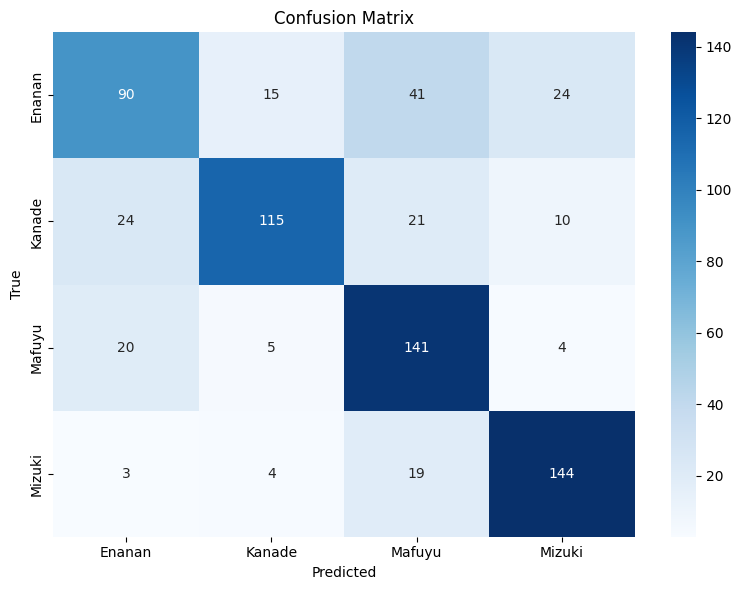

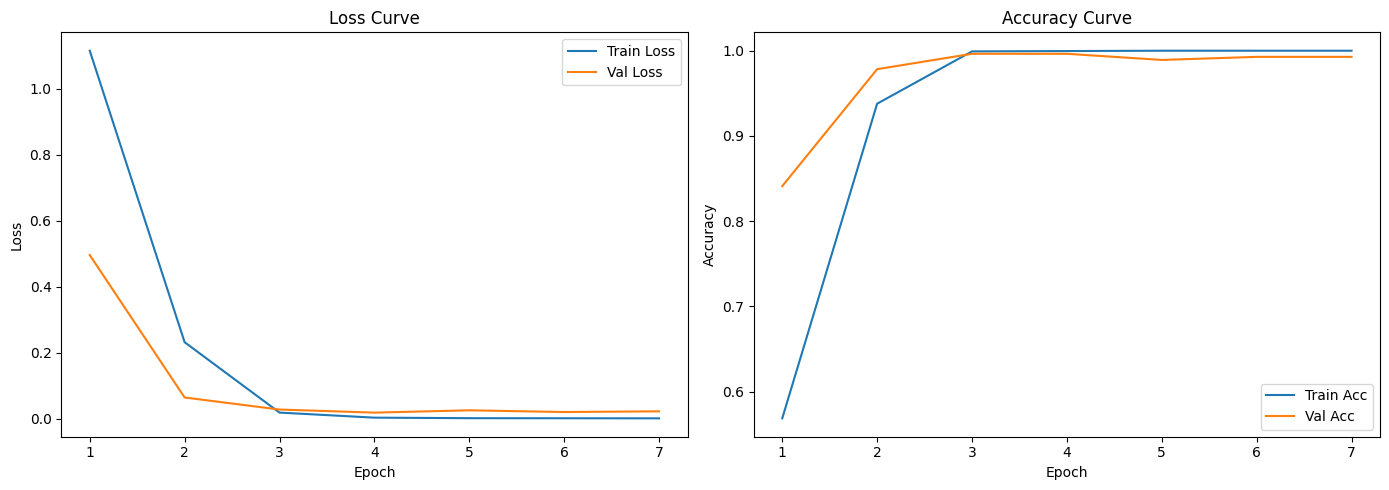

In [20]:
# ==================== Phase 5: 测试评估与可视化 ====================

def plot_history(history_dict):
    """绘制训练过程曲线。"""
    if not history_dict['train_loss']:
        print('当前没有训练历史，先运行训练再绘图。')
        return

    epochs = range(1, len(history_dict['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['train_loss'], label='Train Loss')
    plt.plot(epochs, history_dict['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['train_acc'], label='Train Acc')
    plt.plot(epochs, history_dict['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_on_test(model, loader):
    """在测试集上评估模型，并输出分类报告与混淆矩阵。"""
    test_loss, test_acc, y_true, y_pred = run_epoch(model, loader, criterion, optimizer=None)
    print(f'测试集 Loss: {test_loss:.4f}')
    print(f'测试集 Accuracy: {test_acc:.4f}')
    print('\n分类报告:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return test_loss, test_acc


if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型: {display_project_path(BEST_MODEL_PATH)}')
    _ = evaluate_on_test(model, test_loader)
else:
    print(f'尚未找到最佳模型文件: {display_project_path(BEST_MODEL_PATH)}')
    print('请先将 RUN_TRAINING 设为 True 并运行训练 cell。')

plot_history(history)

## 测试评估与可视化

这一节会在训练结束后加载最佳模型，计算测试集损失、准确率、分类报告和混淆矩阵，并绘制训练曲线。

In [24]:
# ForFun 推理：读取 ForFun 目录下所有图片并输出四人概率
from pathlib import Path
import torch
import torch.nn.functional as F
from PIL import Image

forfun_dir = BASE_DIR / 'ForFun'
if not forfun_dir.exists():
    print(f"ForFun 目录未找到: {forfun_dir}")
else:
    image_paths = sorted([p for p in forfun_dir.rglob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    if not image_paths:
        print(f"在 {forfun_dir} 中未找到图片。")
    else:
        model.eval()
        model.to(device)
        names = CLASS_NAMES if 'CLASS_NAMES' in globals() else [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]
        print('类别顺序:', names)
        for p in image_paths:
            try:
                img = Image.open(p).convert('RGB')
                inp = eval_transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    logits = model(inp)
                    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
                probs_str = ', '.join(f"{n}:{prob:.4f}" for n,prob in zip(names, probs))
                print(f"{p.name} -> {probs_str}")
            except Exception as exc:
                print(f"处理 {p.name} 时出错: {exc}")

类别顺序: ['Enanan', 'Kanade', 'Mafuyu', 'Mizuki']
3DMizuki.jpg -> Enanan:0.5328, Kanade:0.0098, Mafuyu:0.0613, Mizuki:0.3961
ComputerMizuki.jpg -> Enanan:0.0303, Kanade:0.0142, Mafuyu:0.0063, Mizuki:0.9493
Elec2Mizuki.jpg -> Enanan:0.0611, Kanade:0.0066, Mafuyu:0.0124, Mizuki:0.9198
ElecMizuki.jpg -> Enanan:0.3378, Kanade:0.5299, Mafuyu:0.0436, Mizuki:0.0887
Myself1.jpg -> Enanan:0.9649, Kanade:0.0029, Mafuyu:0.0175, Mizuki:0.0147
Myself2.jpg -> Enanan:0.9934, Kanade:0.0024, Mafuyu:0.0017, Mizuki:0.0024
Myself3.jpg -> Enanan:0.8306, Kanade:0.0225, Mafuyu:0.0717, Mizuki:0.0751
PinkStuff.jpg -> Enanan:0.9661, Kanade:0.0032, Mafuyu:0.0039, Mizuki:0.0268
Stuffs.jpg -> Enanan:0.4848, Kanade:0.1802, Mafuyu:0.2210, Mizuki:0.1141
trainEna.jpg -> Enanan:0.9988, Kanade:0.0006, Mafuyu:0.0001, Mizuki:0.0004
